In [5]:
# Cell 1 — Imports and connection
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()
print("Connected.")

Connected.


In [6]:
# Cell 2 — Schema introspection: confirm column names before any SQL
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
    AND table_name = 'int_game_team_features'
    ORDER BY ordinal_position
""")
for row in cur.fetchall():
    print(row)

('game_id', 'bigint')
('season', 'integer')
('week', 'integer')
('game_date', 'date')
('team_name', 'text')
('opponent', 'text')
('points_scored', 'integer')
('points_allowed', 'integer')
('win', 'integer')
('off_epa_per_play', 'numeric')
('def_epa_per_play_allowed', 'numeric')
('close_game_epa_per_play', 'numeric')
('close_game_play_count', 'bigint')
('close_game_def_epa_per_play', 'numeric')
('close_game_def_play_count', 'bigint')
('game_script', 'text')
('game_script_avg_margin', 'numeric')
('last3_off_epa_avg', 'numeric')
('last3_win_pct', 'numeric')
('last3_points_scored_avg', 'numeric')
('last3_def_epa_avg', 'numeric')
('last3_points_allowed_avg', 'numeric')
('days_since_last_game', 'integer')
('opp_sp_rating_at_game_time', 'numeric')
('pregame_elo', 'numeric')
('opponent_pregame_elo', 'numeric')
('postgame_elo', 'numeric')
('excitement_index', 'numeric')


In [7]:
# Cell 3 — Load candidate features, validate EPA columns
candidates = pd.read_csv(os.path.expanduser("~/cfb-analytics/artifacts/candidate_features.csv"))
candidates.columns = candidates.columns.str.strip().str.lower()
keep_cols = set(candidates.loc[candidates["keep"] == True, "column_name"].tolist())

epa_features = [
    "off_epa_per_play",
    "def_epa_per_play_allowed",
    "close_game_epa_per_play",
    "close_game_def_epa_per_play",
    "last3_off_epa_avg",
    "last3_def_epa_avg",
]
print("Candidate feature validation:")
for f in epa_features:
    status = "✓ keep" if f in keep_cols else "✗ NOT in keep list"
    print(f"  {f:40s} {status}")

Candidate feature validation:
  off_epa_per_play                         ✓ keep
  def_epa_per_play_allowed                 ✓ keep
  close_game_epa_per_play                  ✓ keep
  close_game_def_epa_per_play              ✓ keep
  last3_off_epa_avg                        ✓ keep
  last3_def_epa_avg                        ✓ keep


In [8]:
# Cell 4 — Load game-level data with conference join
cur.execute("""
    SELECT
        g.game_id,
        g.season,
        g.week,
        g.team_name,
        g.opponent,
        g.points_scored,
        g.points_allowed,
        g.def_epa_per_play_allowed,
        g.close_game_epa_per_play,
        g.close_game_def_epa_per_play,
        g.close_game_play_count,
        g.close_game_def_play_count,
        g.last3_off_epa_avg,
        g.last3_def_epa_avg,
        g.opp_sp_rating_at_game_time,
        c.conference
    FROM int.int_game_team_features g
    JOIN int.int_team_season_context c
        ON g.team_name = c.team_name AND g.season = c.season
    WHERE g.points_scored IS NOT NULL
      AND g.points_allowed IS NOT NULL
      AND c.conference IN (
          'SEC','Big Ten','Big 12','ACC',
          'Mountain West','American Athletic','Sun Belt',
          'Mid-American','Conference USA','Independent'
      )
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
gdf = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    "points_scored","points_allowed","def_epa_per_play_allowed",
    "close_game_epa_per_play","close_game_def_epa_per_play",
    "close_game_play_count","close_game_def_play_count",
    "last3_off_epa_avg","last3_def_epa_avg","opp_sp_rating_at_game_time"
]
gdf[numeric_cols] = gdf[numeric_cols].astype(float)
gdf["point_differential"] = gdf["points_scored"] - gdf["points_allowed"]
gdf["total_points"] = gdf["points_scored"] + gdf["points_allowed"]

P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

gdf["tier"] = gdf.apply(assign_tier, axis=1)

print(f"Game-level rows        : {len(gdf):,}")
print(f"Seasons                : {sorted(gdf['season'].unique())}")
print(f"Tier split             : {gdf['tier'].value_counts().to_dict()}")
print(f"Conferences            : {sorted(gdf['conference'].unique())}")
print(f"\nNull counts per EPA feature:")
for col in ["close_game_epa_per_play","close_game_def_epa_per_play",
            "def_epa_per_play_allowed","last3_off_epa_avg","last3_def_epa_avg"]:
    n = gdf[col].isna().sum()
    pct = n / len(gdf) * 100
    print(f"  {col:40s} {n:>6,} ({pct:.1f}%)")

Game-level rows        : 5,949
Seasons                : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Tier split             : {'G5': 3016, 'P4': 2933}
Conferences            : ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'Mid-American', 'Mountain West', 'SEC', 'Sun Belt']

Null counts per EPA feature:
  close_game_epa_per_play                       6 (0.1%)
  close_game_def_epa_per_play                   6 (0.1%)
  def_epa_per_play_allowed                      6 (0.1%)
  last3_off_epa_avg                           490 (8.2%)
  last3_def_epa_avg                           490 (8.2%)


In [9]:
# Cell 5 — Load season-level data for YoY and prior-seed analysis
cur.execute("""
    SELECT
        s.team_name,
        s.season,
        s.off_epa_per_play,
        s.def_epa_per_play,
        s.sp_rating,
        s.avg_point_diff,
        s.avg_points_scored,
        s.avg_points_allowed,
        c.conference
    FROM int.int_team_season_features s
    JOIN int.int_team_season_context c
        ON s.team_name = c.team_name AND s.season = c.season
    WHERE s.off_epa_per_play IS NOT NULL
      AND s.def_epa_per_play IS NOT NULL
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
sdf = pd.DataFrame(rows, columns=cols)

season_numeric = [
    "off_epa_per_play","def_epa_per_play","sp_rating",
    "avg_point_diff","avg_points_scored","avg_points_allowed"
]
sdf[season_numeric] = sdf[season_numeric].astype(float)
sdf["tier"] = sdf.apply(assign_tier, axis=1)

print(f"Season-level rows      : {len(sdf):,}")
print(f"Seasons                : {sorted(sdf['season'].unique())}")
print(f"Tier split             : {sdf['tier'].value_counts().to_dict()}")

Season-level rows      : 534
Seasons                : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Tier split             : {'G5': 288, 'P4': 246}


In [10]:
# Cell 6 — Core helpers: partial correlation, OLS summary, bootstrap r
def partial_corr(df, x_col, y_col, control_cols):
    sub = df[[x_col, y_col] + control_cols].dropna()
    n = len(sub)
    if n < 30:
        return np.nan, np.nan, n
    def resid(target, predictors):
        X = sub[predictors].values
        y = sub[target].values
        reg = LinearRegression().fit(X, y)
        return y - reg.predict(X)
    rx = resid(x_col, control_cols)
    ry = resid(y_col, control_cols)
    r, p = stats.pearsonr(rx, ry)
    return r, p, n

def ols_summary(x_cols, y_col, df, label=""):
    sub = df[[y_col] + x_cols].dropna()
    X = sub[x_cols].values
    y = sub[y_col].values
    reg = LinearRegression().fit(X, y)
    yhat = reg.predict(X)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    n, k = len(y), len(x_cols)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    resid_sd = np.std(y - yhat, ddof=k + 1)
    print(f"  {label:45s} R²={r2:.4f}  adj R²={adj_r2:.4f}  resid SD={resid_sd:.4f}  n={n:,}")
    return r2, adj_r2, resid_sd, reg.coef_, reg.intercept_

def bootstrap_r(x, y, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    r_obs, _ = stats.pearsonr(x, y)
    boots = [stats.pearsonr(x[rng.integers(0, len(x), len(x))],
                            y[rng.integers(0, len(x), len(x))])[0]
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return r_obs, lo, hi, len(x)

THRESHOLD = 0.10
print("Helpers defined. Threshold:", THRESHOLD)

Helpers defined. Threshold: 0.1


=== Q1: Inter-feature Pearson correlation matrix (game level) ===

                             close_game_epa_per_play  close_game_def_epa_per_play  def_epa_per_play_allowed  last3_off_epa_avg  last3_def_epa_avg
close_game_epa_per_play                       1.0000                      -0.1660                   -0.1511             0.2337            -0.0450
close_game_def_epa_per_play                  -0.1660                       1.0000                    0.9775            -0.0628             0.1694
def_epa_per_play_allowed                     -0.1511                       0.9775                    1.0000            -0.0595             0.1652
last3_off_epa_avg                             0.2337                      -0.0628                   -0.0595             1.0000            -0.2139
last3_def_epa_avg                            -0.0450                       0.1694                    0.1652            -0.2139             1.0000

Redundancy candidates (|r| > 0.85):
  close_game_def_epa

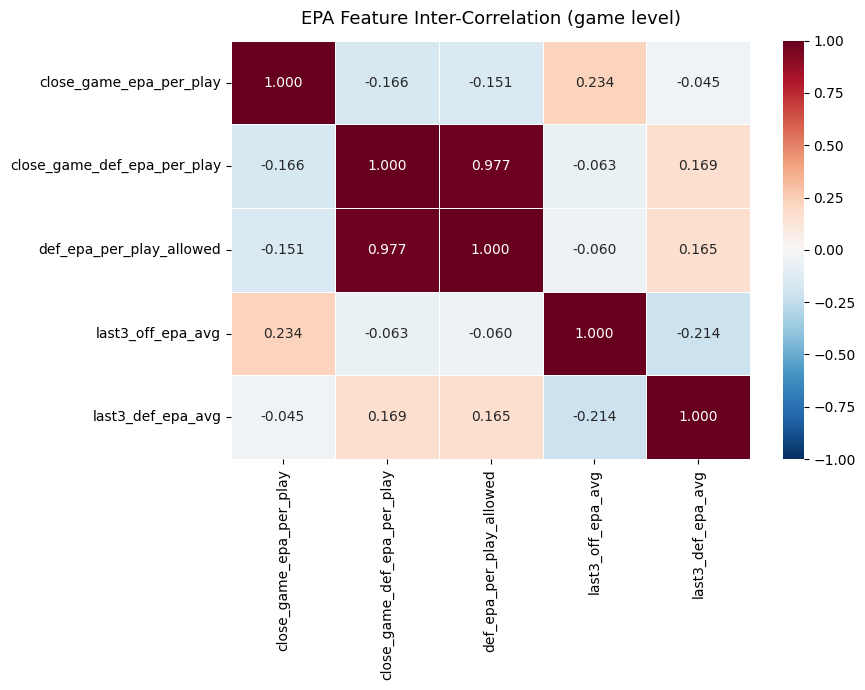

In [11]:
# Cell 7 — Q1: How correlated are EPA features with each other?
# Establishes which features are redundant with each other before
# testing them against outcomes.

EPA_GAME_FEATURES = [
    "close_game_epa_per_play",
    "close_game_def_epa_per_play",
    "def_epa_per_play_allowed",
    "last3_off_epa_avg",
    "last3_def_epa_avg",
]

sub = gdf[EPA_GAME_FEATURES].dropna()
corr = sub.corr(method="pearson")

print("=== Q1: Inter-feature Pearson correlation matrix (game level) ===\n")
print(corr.round(4).to_string())

print("\nRedundancy candidates (|r| > 0.85):")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {corr.columns[i]:40s} <--> {corr.columns[j]:40s}  r={r:.4f}")
            found = True
if not found:
    print("  None found above 0.85 threshold")

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5)
ax.set_title("EPA Feature Inter-Correlation (game level)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [12]:
# Cell 8 — Q2a: Spread signal — individual EPA features vs point_differential
# Regression table + partial r after controlling for opponent quality
# Run separately for all games, P4, and G5

print("=== Q2a: SPREAD SIGNAL — EPA features vs point_differential ===\n")
print("--- OLS: single feature → point_differential ---")
for feat in EPA_GAME_FEATURES:
    ols_summary([feat], "point_differential", gdf, label=feat)

print("\n--- OLS: joint anchor pair → point_differential ---")
anchor = ["close_game_epa_per_play", "close_game_def_epa_per_play"]
r2_joint, adj_r2_joint, resid_sd_joint, coef, intercept = ols_summary(
    anchor, "point_differential", gdf, label="close_game EPA pair (joint)"
)

print("\n--- Partial r after controlling for opp_sp_rating_at_game_time ---")
controls = ["opp_sp_rating_at_game_time"]
print(f"\n{'Feature':40s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>10}")
print("-" * 75)
spread_partial = {}
for feat in EPA_GAME_FEATURES:
    r, p, n = partial_corr(gdf, feat, "point_differential", controls)
    signal = "✓ YES" if abs(r) >= THRESHOLD else "✗ NO"
    print(f"  {feat:38s} {r:>10.4f} {p:>10.4f} {n:>8,} {signal:>10}")
    spread_partial[feat] = {"r": r, "p": p, "n": n}

print("\n--- Partial r by tier (P4 vs G5) ---")
for tier in ["P4", "G5"]:
    print(f"\n  {tier}:")
    tdf = gdf[gdf["tier"] == tier]
    for feat in ["close_game_epa_per_play", "close_game_def_epa_per_play"]:
        r, p, n = partial_corr(tdf, feat, "point_differential", controls)
        signal = "✓" if abs(r) >= THRESHOLD else "✗"
        print(f"    {feat:40s} r={r:.4f}  p={p:.4f}  n={n:,}  {signal}")

=== Q2a: SPREAD SIGNAL — EPA features vs point_differential ===

--- OLS: single feature → point_differential ---
  close_game_epa_per_play                       R²=0.4848  adj R²=0.4848  resid SD=15.8461  n=5,943
  close_game_def_epa_per_play                   R²=0.4695  adj R²=0.4694  resid SD=16.0807  n=5,943
  def_epa_per_play_allowed                      R²=0.4645  adj R²=0.4644  resid SD=16.1563  n=5,943
  last3_off_epa_avg                             R²=0.0387  adj R²=0.0385  resid SD=20.9816  n=5,459
  last3_def_epa_avg                             R²=0.0231  adj R²=0.0229  resid SD=21.1513  n=5,459

--- OLS: joint anchor pair → point_differential ---
  close_game EPA pair (joint)                   R²=0.8023  adj R²=0.8022  resid SD=9.8176  n=5,943

--- Partial r after controlling for opp_sp_rating_at_game_time ---

Feature                                   partial_r          p        n     signal
---------------------------------------------------------------------------
  clos

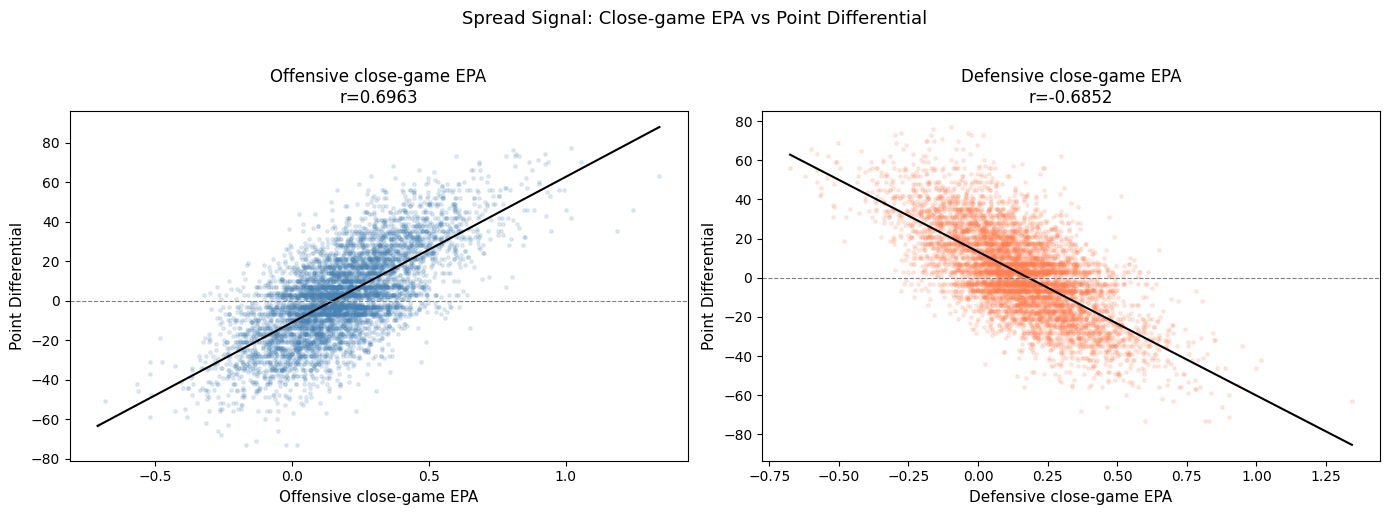

In [13]:
# Cell 9 — Q2a scatter: close_game EPA pair vs point_differential
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, color, label in zip(
    axes,
    ["close_game_epa_per_play", "close_game_def_epa_per_play"],
    ["steelblue", "coral"],
    ["Offensive close-game EPA", "Defensive close-game EPA"]
):
    sub = gdf[[feat, "point_differential"]].dropna()
    x = sub[feat].values
    y = sub["point_differential"].values
    ax.scatter(x, y, alpha=0.15, s=6, color=color)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color="black", lw=1.5)
    r, _ = stats.pearsonr(x, y)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Point Differential", fontsize=11)
    ax.set_title(f"{label}\nr={r:.4f}", fontsize=12)
    ax.axhline(0, color="gray", lw=0.8, ls="--")

plt.suptitle("Spread Signal: Close-game EPA vs Point Differential", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Cell 10 — Q2b: Over/Under signal — EPA features vs total_points
# Same depth as spread section

print("=== Q2b: OVER/UNDER SIGNAL — EPA features vs total_points ===\n")
print("--- OLS: single feature → total_points ---")
for feat in EPA_GAME_FEATURES:
    ols_summary([feat], "total_points", gdf, label=feat)

print("\n--- OLS: joint anchor pair → total_points ---")
r2_ou_joint, adj_r2_ou_joint, resid_sd_ou_joint, coef_ou, intercept_ou = ols_summary(
    anchor, "total_points", gdf, label="close_game EPA pair (joint)"
)

print("\n--- Partial r after controlling for opp_sp_rating_at_game_time ---")
print(f"\n{'Feature':40s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>10}")
print("-" * 75)
ou_partial = {}
for feat in EPA_GAME_FEATURES:
    r, p, n = partial_corr(gdf, feat, "total_points", controls)
    signal = "✓ YES" if abs(r) >= THRESHOLD else "✗ NO"
    print(f"  {feat:38s} {r:>10.4f} {p:>10.4f} {n:>8,} {signal:>10}")
    ou_partial[feat] = {"r": r, "p": p, "n": n}

print("\n--- Partial r by tier (P4 vs G5) ---")
for tier in ["P4", "G5"]:
    print(f"\n  {tier}:")
    tdf = gdf[gdf["tier"] == tier]
    for feat in ["close_game_epa_per_play", "close_game_def_epa_per_play"]:
        r, p, n = partial_corr(tdf, feat, "total_points", controls)
        signal = "✓" if abs(r) >= THRESHOLD else "✗"
        print(f"    {feat:40s} r={r:.4f}  p={p:.4f}  n={n:,}  {signal}")

=== Q2b: OVER/UNDER SIGNAL — EPA features vs total_points ===

--- OLS: single feature → total_points ---
  close_game_epa_per_play                       R²=0.1898  adj R²=0.1896  resid SD=15.1054  n=5,943
  close_game_def_epa_per_play                   R²=0.1562  adj R²=0.1560  resid SD=15.4154  n=5,943
  def_epa_per_play_allowed                      R²=0.1704  adj R²=0.1703  resid SD=15.2845  n=5,943
  last3_off_epa_avg                             R²=0.0095  adj R²=0.0094  resid SD=16.6822  n=5,459
  last3_def_epa_avg                             R²=0.0091  adj R²=0.0089  resid SD=16.6856  n=5,459

--- OLS: joint anchor pair → total_points ---
  close_game EPA pair (joint)                   R²=0.4265  adj R²=0.4263  resid SD=12.7096  n=5,943

--- Partial r after controlling for opp_sp_rating_at_game_time ---

Feature                                   partial_r          p        n     signal
---------------------------------------------------------------------------
  close_game_epa_pe

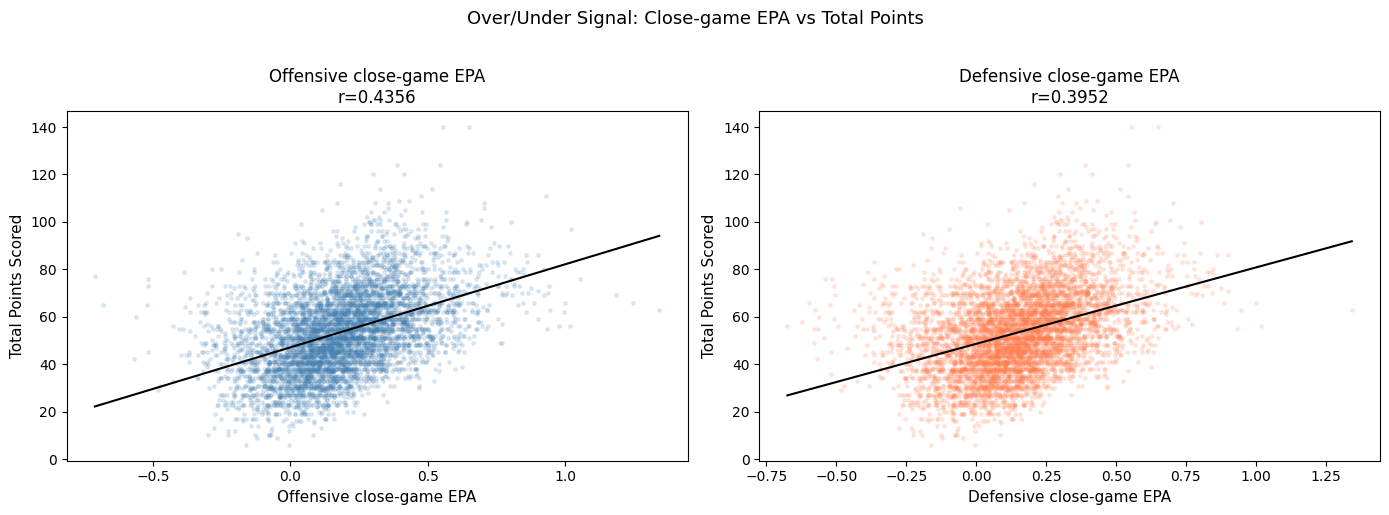

In [15]:
# Cell 11 — Q2b scatter: close_game EPA pair vs total_points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, color, label in zip(
    axes,
    ["close_game_epa_per_play", "close_game_def_epa_per_play"],
    ["steelblue", "coral"],
    ["Offensive close-game EPA", "Defensive close-game EPA"]
):
    sub = gdf[[feat, "total_points"]].dropna()
    x = sub[feat].values
    y = sub["total_points"].values
    ax.scatter(x, y, alpha=0.15, s=6, color=color)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color="black", lw=1.5)
    r, _ = stats.pearsonr(x, y)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Total Points Scored", fontsize=11)
    ax.set_title(f"{label}\nr={r:.4f}", fontsize=12)

plt.suptitle("Over/Under Signal: Close-game EPA vs Total Points", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Cell 12 — Q3: Moneyline variance signal
# Does the feature predict score distribution variance?
# Method 1: SD of point_differential by feature quartile
# Method 2: Does high EPA predict tighter or wider score distributions?
# A feature that predicts variance is a moneyline signal independent of direction.

print("=== Q3: MONEYLINE VARIANCE SIGNAL ===\n")
print("Does the feature predict the variance of the score distribution?")
print("SD of point_differential by feature quartile — range > 3 pts = signal\n")

variance_results = []
for feat in ["close_game_epa_per_play", "close_game_def_epa_per_play",
             "def_epa_per_play_allowed"]:
    sub = gdf[[feat, "point_differential", "total_points"]].dropna()
    sub = sub.copy()
    sub["quartile"] = pd.qcut(sub[feat], q=4, labels=["Q1","Q2","Q3","Q4"])

    grp_diff = sub.groupby("quartile")["point_differential"].agg(["mean","std","count"])
    grp_total = sub.groupby("quartile")["total_points"].agg(["mean","std","count"])

    sd_range_diff = grp_diff["std"].max() - grp_diff["std"].min()
    sd_range_total = grp_total["std"].max() - grp_total["std"].min()

    print(f"{feat}")
    print(f"  point_differential SD by quartile:")
    for q in ["Q1","Q2","Q3","Q4"]:
        print(f"    {q}: mean={grp_diff.loc[q,'mean']:+.2f}  SD={grp_diff.loc[q,'std']:.2f}  n={int(grp_diff.loc[q,'count']):,}")
    print(f"  SD range (max-min): {sd_range_diff:.2f} pts  ->  {'✓ variance signal' if sd_range_diff > 3 else '✗ no variance signal'}")

    print(f"  total_points SD by quartile:")
    for q in ["Q1","Q2","Q3","Q4"]:
        print(f"    {q}: mean={grp_total.loc[q,'mean']:.2f}  SD={grp_total.loc[q,'std']:.2f}  n={int(grp_total.loc[q,'count']):,}")
    print(f"  SD range (max-min): {sd_range_total:.2f} pts  ->  {'✓ variance signal' if sd_range_total > 3 else '✗ no variance signal'}")
    print()

    variance_results.append({
        "feature": feat,
        "sd_range_point_diff": sd_range_diff,
        "sd_range_total_points": sd_range_total,
        "moneyline_variance_signal_spread": sd_range_diff > 3,
        "moneyline_variance_signal_ou": sd_range_total > 3,
    })

=== Q3: MONEYLINE VARIANCE SIGNAL ===

Does the feature predict the variance of the score distribution?
SD of point_differential by feature quartile — range > 3 pts = signal

close_game_epa_per_play
  point_differential SD by quartile:
    Q1: mean=-16.11  SD=17.63  n=1,486
    Q2: mean=-2.69  SD=15.36  n=1,486
    Q3: mean=+5.59  SD=16.09  n=1,485
    Q4: mean=+22.31  SD=19.21  n=1,486
  SD range (max-min): 3.86 pts  ->  ✓ variance signal
  total_points SD by quartile:
    Q1: mean=44.50  SD=15.32  n=1,486
    Q2: mean=48.84  SD=14.57  n=1,486
    Q3: mean=56.17  SD=14.63  n=1,485
    Q4: mean=64.15  SD=15.56  n=1,486
  SD range (max-min): 0.99 pts  ->  ✗ no variance signal

close_game_def_epa_per_play
  point_differential SD by quartile:
    Q1: mean=+21.90  SD=18.76  n=1,486
    Q2: mean=+6.09  SD=15.79  n=1,486
    Q3: mean=-2.53  SD=15.61  n=1,485
    Q4: mean=-16.37  SD=18.27  n=1,486
  SD range (max-min): 3.15 pts  ->  ✓ variance signal
  total_points SD by quartile:
    Q1: mea

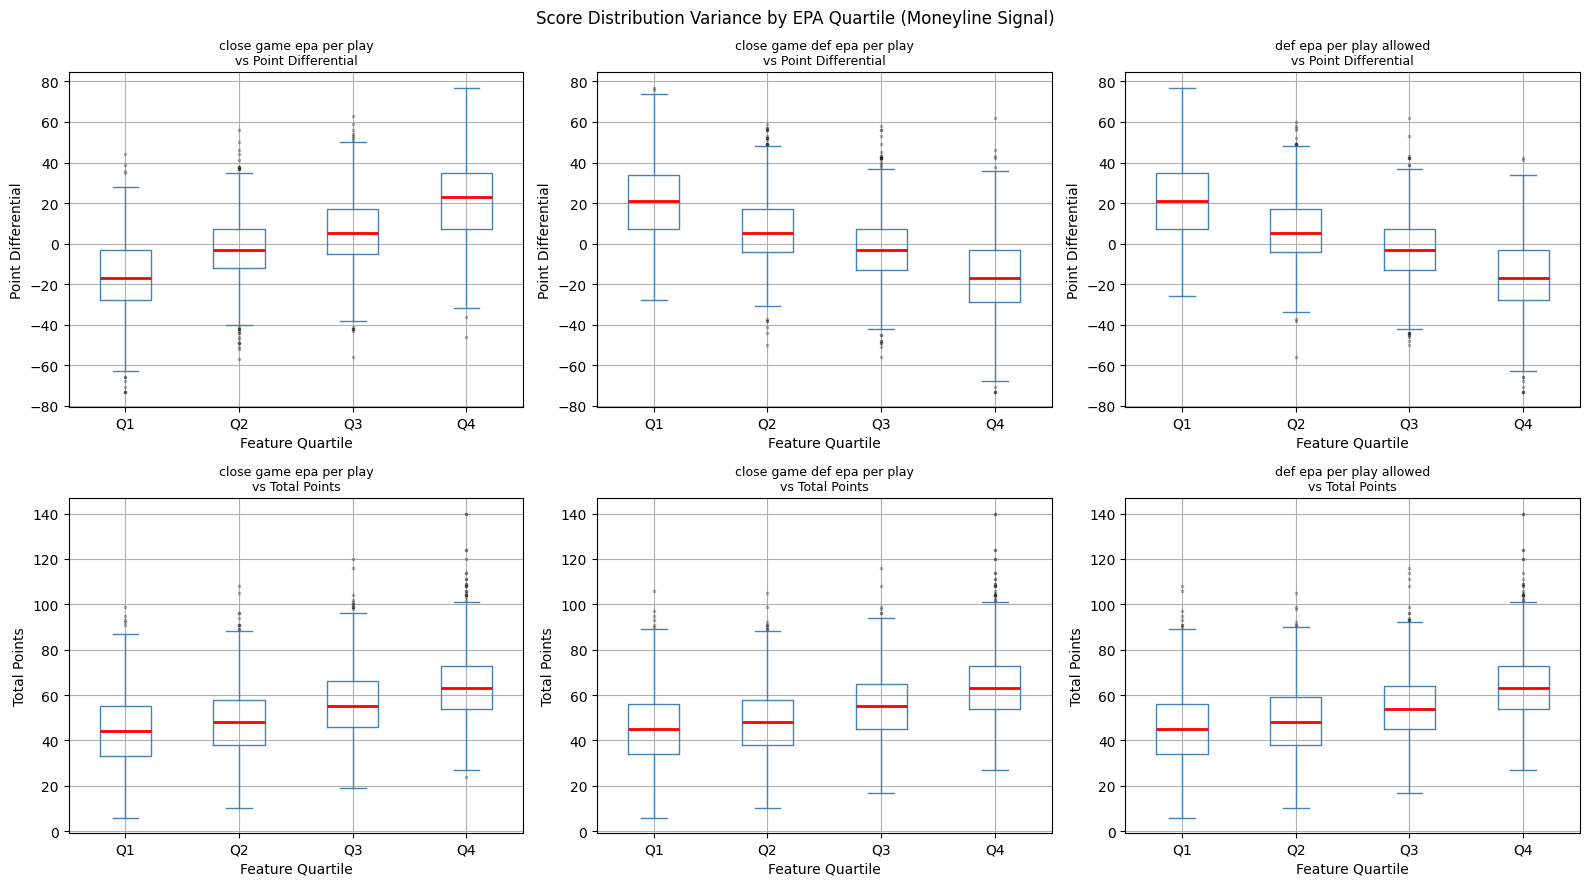

In [17]:
# Cell 13 — Q3 visualization: score distribution variance by EPA quartile
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

feats = ["close_game_epa_per_play", "close_game_def_epa_per_play", "def_epa_per_play_allowed"]
targets = [("point_differential", "Point Differential"), ("total_points", "Total Points")]

for col_idx, feat in enumerate(feats):
    for row_idx, (target, target_label) in enumerate(targets):
        ax = axes[row_idx][col_idx]
        sub = gdf[[feat, target]].dropna().copy()
        sub["quartile"] = pd.qcut(sub[feat], q=4, labels=["Q1","Q2","Q3","Q4"])
        sub.boxplot(column=target, by="quartile", ax=ax,
                   boxprops=dict(color="steelblue"),
                   medianprops=dict(color="red", lw=2),
                   whiskerprops=dict(color="steelblue"),
                   capprops=dict(color="steelblue"),
                   flierprops=dict(marker=".", alpha=0.3, ms=3))
        ax.set_title(f"{feat.replace('_',' ')}\nvs {target_label}", fontsize=9)
        ax.set_xlabel("Feature Quartile")
        ax.set_ylabel(target_label)

plt.suptitle("Score Distribution Variance by EPA Quartile (Moneyline Signal)", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# Cell 14 — Q4: Within-season trajectory
# Conference game number derived from actual conference opponents
# Join to get opponent's conference, filter to games where both teams
# are FBS conference members — these are true conference games

print("=== Q4: WITHIN-SEASON TRAJECTORY ===\n")
print("Does spread and O/U signal hold across the conference season arc?")
print("Conference game number assigned from actual conference matchups only\n")

# Get opponent conference to identify true conference games
cur.execute("""
    SELECT
        g.game_id,
        g.team_name,
        g.season,
        opp_ctx.conference AS opp_conference
    FROM int.int_game_team_features g
    JOIN int.int_team_season_context opp_ctx
        ON g.opponent = opp_ctx.team_name AND g.season = opp_ctx.season
""")
opp_rows = cur.fetchall()
opp_cols = [d[0] for d in cur.description]
opp_df = pd.DataFrame(opp_rows, columns=opp_cols)

# Merge opponent conference into gdf
gdf_opp = gdf.merge(opp_df, on=["game_id","team_name","season"], how="left")

# True conference games: both teams in same FBS conference
# (opponent must be in same conference as focal team)
gdf_opp["same_conference"] = gdf_opp["conference"] == gdf_opp["opp_conference"]
gdf_conf = gdf_opp[gdf_opp["same_conference"] == True].copy()

print(f"Total game rows        : {len(gdf):,}")
print(f"True conference games  : {len(gdf_conf):,}")
print(f"Seasons                : {sorted(gdf_conf['season'].unique())}")

# Assign conference game number per team-season
gdf_conf = gdf_conf.sort_values(["team_name","season","week"])
gdf_conf["conf_game_num"] = gdf_conf.groupby(
    ["team_name","season"]
).cumcount() + 1

print(f"\nConference game number distribution:")
print(gdf_conf["conf_game_num"].value_counts().sort_index().head(15))

print(f"\nNull rate of opp_sp_rating_at_game_time in conf games:")
n_null = gdf_conf["opp_sp_rating_at_game_time"].isna().sum()
print(f"  {n_null:,} / {len(gdf_conf):,} ({n_null/len(gdf_conf)*100:.1f}%)")
print(f"  By season:")
for s, grp in gdf_conf.groupby("season"):
    n = grp["opp_sp_rating_at_game_time"].isna().sum()
    print(f"    {s}: {n:,} / {len(grp):,} null ({n/len(grp)*100:.1f}%)")

bands = {
    "conf_game_1":    gdf_conf[gdf_conf["conf_game_num"] == 1],
    "conf_games_2_4": gdf_conf[gdf_conf["conf_game_num"].between(2, 4)],
    "conf_games_5_8": gdf_conf[gdf_conf["conf_game_num"].between(5, 8)],
    "conf_games_9_12":gdf_conf[gdf_conf["conf_game_num"].between(9, 12)],
}

band_labels = {
    "conf_game_1":    "Conf game 1    (prior only)",
    "conf_games_2_4": "Conf games 2-4 (posterior developing)",
    "conf_games_5_8": "Conf games 5-8 (posterior informed)",
    "conf_games_9_12":"Conf games 9-12 (fully informed)",
}

trajectory_features = [
    "close_game_epa_per_play",
    "close_game_def_epa_per_play",
    "def_epa_per_play_allowed",
    "last3_off_epa_avg",
    "last3_def_epa_avg",
]

for feat in trajectory_features:
    print(f"\n{feat}")
    print(f"  {'Band':40s} {'n':>6} {'spread_r':>10} {'spread_sig':>12} {'ou_r':>10} {'ou_sig':>10}")
    print(f"  {'-'*93}")
    for band_key, band_label in band_labels.items():
        band_df = bands[band_key]
        r_s, p_s, n = partial_corr(band_df, feat, "point_differential",
                                   ["opp_sp_rating_at_game_time"])
        r_o, p_o, _ = partial_corr(band_df, feat, "total_points",
                                   ["opp_sp_rating_at_game_time"])
        ss = "✓" if (not np.isnan(r_s) and abs(r_s) >= THRESHOLD) else "✗"
        os_ = "✓" if (not np.isnan(r_o) and abs(r_o) >= THRESHOLD) else "✗"
        r_s_str = f"{r_s:.4f}" if not np.isnan(r_s) else "  nan "
        r_o_str = f"{r_o:.4f}" if not np.isnan(r_o) else "  nan "
        print(f"  {band_label:40s} {n:>6,} {r_s_str:>10} {ss:>12} {r_o_str:>10} {os_:>10}")

=== Q4: WITHIN-SEASON TRAJECTORY ===

Does spread and O/U signal hold across the conference season arc?
Conference game number assigned from actual conference matchups only

Total game rows        : 5,949
True conference games  : 4,110
Seasons                : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Conference game number distribution:
conf_game_num
1     490
2     490
3     490
4     490
5     490
6     490
7     490
8     478
9     178
10     24
Name: count, dtype: int64

Null rate of opp_sp_rating_at_game_time in conf games:
  976 / 4,110 (23.7%)
  By season:
    2022: 936 / 936 null (100.0%)
    2023: 16 / 982 null (1.6%)
    2024: 8 / 1,078 null (0.7%)
    2025: 16 / 1,114 null (1.4%)

close_game_epa_per_play
  Band                                          n   spread_r   spread_sig       ou_r     ou_sig
  ---------------------------------------------------------------------------------------------
  Conf game 1    (prior only)                 373     0.58

point_differential | close_game_epa_per_play: [0.58449986 0.61331898 0.63987496 0.61723534]
point_differential | close_game_def_epa_per_play: [-0.58664487 -0.62292601 -0.63161546 -0.63174994]
total_points | close_game_epa_per_play: [0.43375014 0.44810225 0.44930151 0.52723353]
total_points | close_game_def_epa_per_play: [0.47073864 0.46024467 0.45408608 0.51767954]


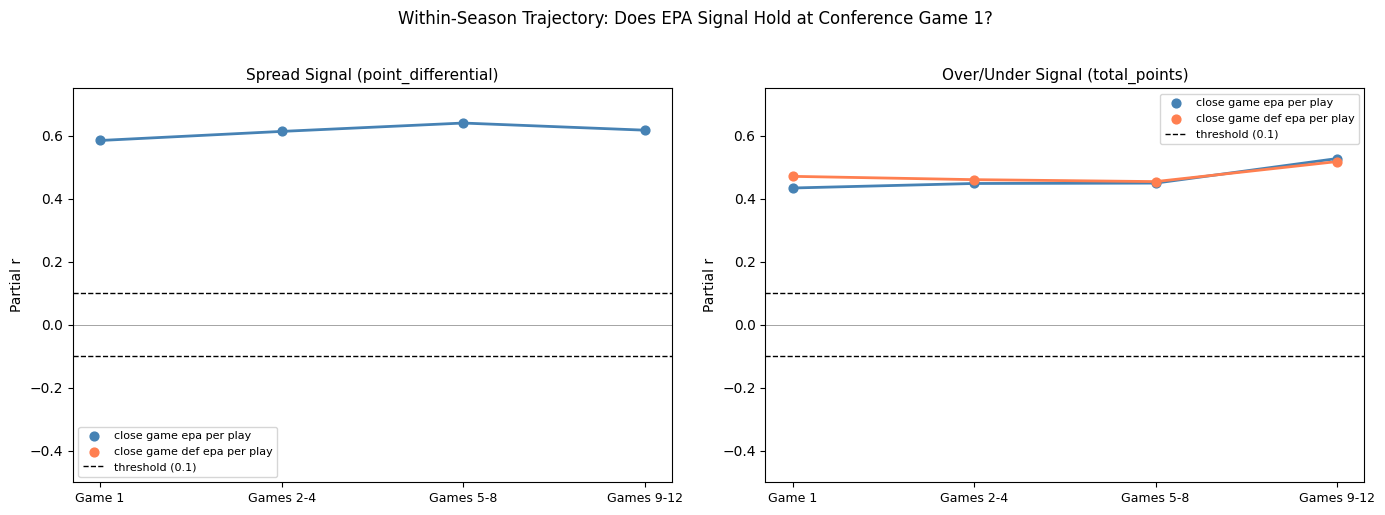

In [22]:
# Cell 15 — Q4 visualization: trajectory of partial r across conference season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

band_names = list(band_labels.keys())
band_short = ["Game 1", "Games 2-4", "Games 5-8", "Games 9-12"]
x = np.arange(len(band_names))

for ax, target, target_label in zip(
    axes,
    ["point_differential", "total_points"],
    ["Spread Signal (point_differential)", "Over/Under Signal (total_points)"]
):
    for feat, color in zip(
        ["close_game_epa_per_play", "close_game_def_epa_per_play"],
        ["steelblue", "coral"]
    ):
        rs = []
        for band_key in band_names:
            band_df = bands[band_key]
            r, p, n = partial_corr(band_df, feat, target,
                                   ["opp_sp_rating_at_game_time"])
            rs.append(float(r) if not np.isnan(r) else np.nan)

        rs_arr = np.array(rs, dtype=float)
        print(f"{target} | {feat}: {rs_arr}")

        # Plot segments between non-nan points
        for i in range(len(rs_arr) - 1):
            if not np.isnan(rs_arr[i]) and not np.isnan(rs_arr[i+1]):
                ax.plot([x[i], x[i+1]], [rs_arr[i], rs_arr[i+1]],
                        color=color, lw=2)
        valid_x = x[~np.isnan(rs_arr)]
        valid_y = rs_arr[~np.isnan(rs_arr)]
        ax.scatter(valid_x, valid_y, color=color, s=40, zorder=5,
                   label=feat.replace("_", " "))

    ax.axhline(THRESHOLD, color="black", lw=1, ls="--",
               label=f"threshold ({THRESHOLD})")
    ax.axhline(-THRESHOLD, color="black", lw=1, ls="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(band_short, fontsize=9)
    ax.set_ylabel("Partial r")
    ax.set_title(target_label, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.5, 0.75)

plt.suptitle("Within-Season Trajectory: Does EPA Signal Hold at Conference Game 1?",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Cell 16 — Q5: YoY stability of season-level EPA
# Season N vs season N+1 Pearson r with bootstrap CI
# Benchmarks: off_epa r=0.423, def_epa r=0.393, sp_rating r=0.761

print("=== Q5: YoY STABILITY — season-level EPA ===\n")
print("Benchmarks: off_epa r=0.423 | def_epa r=0.393 | sp_rating r=0.761")
print("Threshold for prior anchor: r >= 0.60\n")

sdf_n = sdf.copy()
sdf_n1 = sdf.copy()
sdf_n1["season"] = sdf_n1["season"] - 1
yoy = sdf_n.merge(sdf_n1, on=["team_name","season"], suffixes=("_n","_n1"))

print(f"YoY pairs available: {len(yoy):,}")
print(f"\n{'Feature':30s} {'r':>8} {'95% CI lo':>12} {'95% CI hi':>12} "
      f"{'n':>6} {'stable r>=0.60':>16}")
print("-" * 90)

for feat in ["off_epa_per_play", "def_epa_per_play"]:
    r, lo, hi, n = bootstrap_r(
        yoy[f"{feat}_n"].values,
        yoy[f"{feat}_n1"].values
    )
    stable = "✓ YES" if r >= 0.60 else "✗ NO"
    print(f"  {feat:28s} {r:>8.4f} {lo:>12.4f} {hi:>12.4f} {n:>6,} {stable:>16}")

=== Q5: YoY STABILITY — season-level EPA ===

Benchmarks: off_epa r=0.423 | def_epa r=0.393 | sp_rating r=0.761
Threshold for prior anchor: r >= 0.60

YoY pairs available: 398

Feature                               r    95% CI lo    95% CI hi      n   stable r>=0.60
------------------------------------------------------------------------------------------
  off_epa_per_play               0.4151      -0.0948       0.1017    398             ✗ NO
  def_epa_per_play               0.3883      -0.0961       0.0919    398             ✗ NO


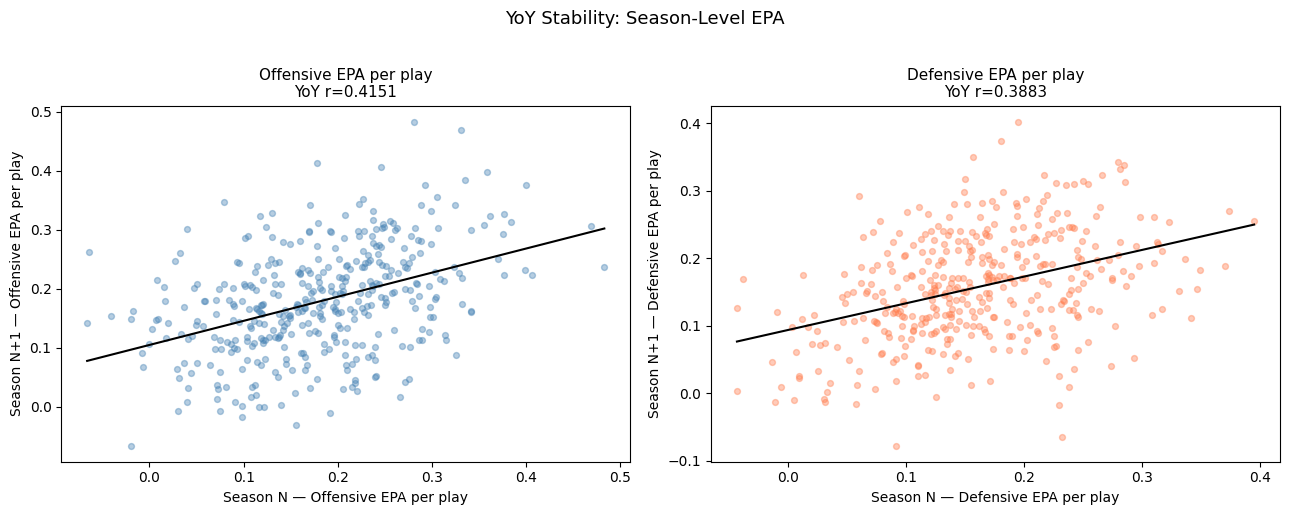

In [24]:
# Cell 17 — Q5 visualization: YoY scatter for off and def EPA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, color, label in zip(
    axes,
    ["off_epa_per_play", "def_epa_per_play"],
    ["steelblue", "coral"],
    ["Offensive EPA per play", "Defensive EPA per play"]
):
    sub = yoy[[f"{feat}_n", f"{feat}_n1"]].dropna()
    x = sub[f"{feat}_n"].values
    y = sub[f"{feat}_n1"].values
    ax.scatter(x, y, alpha=0.4, s=18, color=color)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color="black", lw=1.5)
    r, _ = stats.pearsonr(x, y)
    ax.set_xlabel(f"Season N — {label}", fontsize=10)
    ax.set_ylabel(f"Season N+1 — {label}", fontsize=10)
    ax.set_title(f"{label}\nYoY r={r:.4f}", fontsize=11)

plt.suptitle("YoY Stability: Season-Level EPA", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Cell 18 — Q6: Residual analysis
# After controlling for the close_game EPA anchor pair,
# what residual variance is left?
# Do other EPA features (def_epa_per_play_allowed, last3 features)
# explain any of that residual for spread or O/U?

print("=== Q6: RESIDUAL ANALYSIS ===\n")
print("After close_game EPA pair, what residual does each feature explain?")
print("Tested against both point_differential (spread) and total_points (O/U)\n")

anchor = ["close_game_epa_per_play", "close_game_def_epa_per_play"]
residual_candidates = [
    "def_epa_per_play_allowed",
    "last3_off_epa_avg",
    "last3_def_epa_avg",
]

for target, target_label in [
    ("point_differential", "point_differential (SPREAD)"),
    ("total_points", "total_points (O/U)")
]:
    print(f"--- Target: {target_label} ---")
    sub_base = gdf[anchor + [target]].dropna()
    X_base = sub_base[anchor].values
    y_base = sub_base[target].values
    reg_base = LinearRegression().fit(X_base, y_base)
    resid_base = y_base - reg_base.predict(X_base)

    ss_tot = np.sum((y_base - y_base.mean()) ** 2)
    ss_res = np.sum(resid_base ** 2)
    r2_base = 1 - ss_res / ss_tot
    print(f"  Anchor pair R²={r2_base:.4f}  resid SD={np.std(resid_base, ddof=3):.4f} pts  n={len(y_base):,}")

    print(f"\n  {'Candidate feature':40s} {'resid_r':>10} {'p':>10} {'signal':>10}")
    print(f"  {'-'*75}")
    for feat in residual_candidates:
        sub_r = gdf[anchor + [target, feat]].dropna()
        if len(sub_r) < 100:
            print(f"  {feat:40s} {'insufficient data':>30}")
            continue
        X_r = sub_r[anchor].values
        y_r = sub_r[target].values
        reg_r = LinearRegression().fit(X_r, y_r)
        resid_r = y_r - reg_r.predict(X_r)
        feat_vals = sub_r[feat].values
        r_resid, p_resid = stats.pearsonr(feat_vals, resid_r)
        signal = "✓ YES" if abs(r_resid) >= THRESHOLD else "✗ NO"
        print(f"  {feat:40s} {r_resid:>10.4f} {p_resid:>10.4f} {signal:>10}")
    print()

=== Q6: RESIDUAL ANALYSIS ===

After close_game EPA pair, what residual does each feature explain?
Tested against both point_differential (spread) and total_points (O/U)

--- Target: point_differential (SPREAD) ---
  Anchor pair R²=0.8023  resid SD=9.8176 pts  n=5,943

  Candidate feature                           resid_r          p     signal
  ---------------------------------------------------------------------------
  def_epa_per_play_allowed                    -0.0405     0.0018       ✗ NO
  last3_off_epa_avg                            0.0479     0.0004       ✗ NO
  last3_def_epa_avg                           -0.0602     0.0000       ✗ NO

--- Target: total_points (O/U) ---
  Anchor pair R²=0.4265  resid SD=12.7096 pts  n=5,943

  Candidate feature                           resid_r          p     signal
  ---------------------------------------------------------------------------
  def_epa_per_play_allowed                     0.0288     0.0266       ✗ NO
  last3_off_epa_avg       

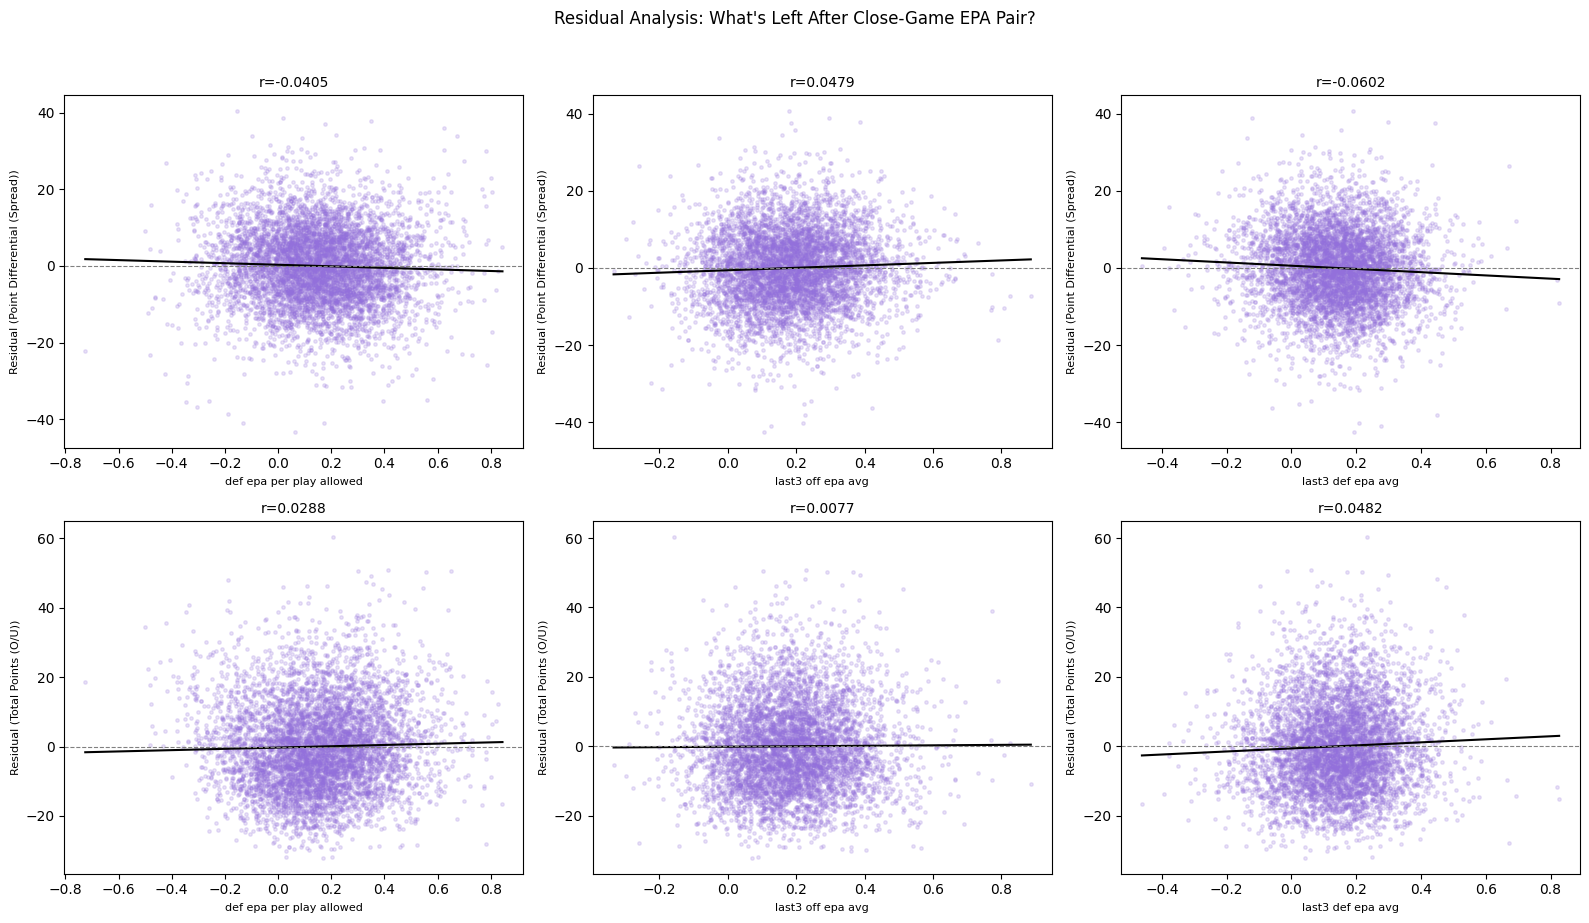

In [26]:
# Cell 19 — Q6 visualization: residual scatter plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row_idx, (target, target_label) in enumerate([
    ("point_differential", "Point Differential (Spread)"),
    ("total_points", "Total Points (O/U)")
]):
    sub_base = gdf[anchor + [target]].dropna()
    X_base = sub_base[anchor].values
    y_base = sub_base[target].values
    reg_base = LinearRegression().fit(X_base, y_base)
    resid_base_full = y_base - reg_base.predict(X_base)

    for col_idx, feat in enumerate(residual_candidates):
        ax = axes[row_idx][col_idx]
        sub_r = gdf[anchor + [target, feat]].dropna()
        if len(sub_r) < 100:
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                    transform=ax.transAxes)
            continue
        X_r = sub_r[anchor].values
        y_r = sub_r[target].values
        reg_r = LinearRegression().fit(X_r, y_r)
        resid_r = y_r - reg_r.predict(X_r)
        feat_vals = sub_r[feat].values
        r_resid, _ = stats.pearsonr(feat_vals, resid_r)

        ax.scatter(feat_vals, resid_r, alpha=0.2, s=6, color="mediumpurple")
        m, b = np.polyfit(feat_vals, resid_r, 1)
        xline = np.linspace(feat_vals.min(), feat_vals.max(), 200)
        ax.plot(xline, m * xline + b, color="black", lw=1.5)
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_xlabel(feat.replace("_", " "), fontsize=8)
        ax.set_ylabel(f"Residual ({target_label})", fontsize=8)
        ax.set_title(f"r={r_resid:.4f}", fontsize=10)

plt.suptitle("Residual Analysis: What's Left After Close-Game EPA Pair?",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [30]:
# Cell 20 — Full verdict table, populated from in-memory results

# Collect trajectory results into a dict
trajectory_results = {}
for feat in trajectory_features:
    trajectory_results[feat] = {}
    for band_key, band_label in band_labels.items():
        band_df = bands[band_key]
        r_s, p_s, n = partial_corr(band_df, feat, "point_differential",
                                   ["opp_sp_rating_at_game_time"])
        r_o, p_o, _ = partial_corr(band_df, feat, "total_points",
                                   ["opp_sp_rating_at_game_time"])
        trajectory_results[feat][band_key] = {
            "spread_r": r_s, "ou_r": r_o, "n": n
        }

# Collect YoY results
yoy_lookup = {}
for feat, proxy, is_prior_seed in [
    ("close_game_epa_per_play",     "off_epa_per_play", False),
    ("close_game_def_epa_per_play", "def_epa_per_play", False),
    ("def_epa_per_play_allowed",    "def_epa_per_play", False),
    ("last3_off_epa_avg",           None,               False),
    ("last3_def_epa_avg",           None,               False),
]:
    if proxy is None:
        yoy_lookup[feat] = {
            "r": np.nan, "stable": False,
            "note": "N/A — rolling feature",
            "is_prior_seed": is_prior_seed
        }
    else:
        r, lo, hi, n = bootstrap_r(
            yoy[f"{proxy}_n"].values,
            yoy[f"{proxy}_n1"].values
        )
        yoy_lookup[feat] = {
            "r": r, "stable": r >= 0.60,
            "note": f"proxy={proxy} r={r:.4f}",
            "is_prior_seed": is_prior_seed
        }

# Collect variance results into dict
variance_lookup = {v["feature"]: v for v in variance_results}

# Build verdict rows
verdict_rows = []
print("=" * 90)
print("EPA DEEP DIVE — FULL VERDICT")
print("=" * 90)

for feat in trajectory_features:
    sp  = spread_partial.get(feat, {})
    ou  = ou_partial.get(feat, {})
    var = variance_lookup.get(feat, {})
    yoy_r = yoy_lookup.get(feat, {})
    traj  = trajectory_results.get(feat, {})

    spread_r   = sp.get("r", np.nan)
    spread_sig = not np.isnan(spread_r) and abs(spread_r) >= THRESHOLD
    ou_r       = ou.get("r", np.nan)
    ou_sig     = not np.isnan(ou_r) and abs(ou_r) >= THRESHOLD
    var_spread = var.get("moneyline_variance_signal_spread", False)
    var_ou     = var.get("moneyline_variance_signal_ou", False)
    yoy_stable = yoy_r.get("stable", False)
    yoy_r_val  = yoy_r.get("r", np.nan)
    is_prior_seed = yoy_r.get("is_prior_seed", False)

    traj_g1           = traj.get("conf_game_1", {})
    traj_spread_g1    = traj_g1.get("spread_r", np.nan)
    traj_ou_g1        = traj_g1.get("ou_r", np.nan)
    traj_spread_holds = not np.isnan(traj_spread_g1) and abs(traj_spread_g1) >= THRESHOLD
    traj_ou_holds     = not np.isnan(traj_ou_g1) and abs(traj_ou_g1) >= THRESHOLD

    # Verdict logic
    # YoY stability gates prior seed features only.
    # Game-level predictors are judged on spread/O/U signal and trajectory alone.
    # Rolling features (last3) cannot be prior seeds — they reset each season.
    if feat in ["last3_off_epa_avg", "last3_def_epa_avg"]:
        # Not opponent-adjusted. Zero residual after anchor pair.
        # Rolling features with no residual signal are redundant.
        if spread_sig or ou_sig:
            verdict = "supporting — in-season only, not opponent-adjusted, no prior seed"
        else:
            verdict = "redundant — no residual signal after anchor pair, not opponent-adjusted"

    elif feat == "def_epa_per_play_allowed":
        # r=0.9775 with close_game_def_epa_per_play — collinear.
        # Zero residual signal after anchor pair for both spread and O/U.
        verdict = "redundant — collinear with close_game_def_epa_per_play (r=0.9775), zero residual signal"

    else:
        # Game-level predictors: close_game_epa_per_play, close_game_def_epa_per_play
        # YoY stability is NOT the gating criterion — these are not prior seeds.
        # They are game-level signals. Prior seed is off/def_epa_per_play (season-level).
        # Verdict depends on: signal strength, trajectory holding at game 1, both outputs.
        has_signal = spread_sig and ou_sig
        holds_game1 = traj_spread_holds and traj_ou_holds

        if has_signal and holds_game1:
            verdict = "anchor candidate — game-level predictor, spread + O/U signal, holds at conf game 1"
        elif has_signal:
            verdict = "supporting — signal present but degrades at conf game 1"
        elif spread_sig:
            verdict = "supporting — spread signal only"
        elif ou_sig:
            verdict = "supporting — O/U signal only"
        else:
            verdict = "redundant"

    print(f"\nFEATURE: {feat}")
    print(f"  Spread signal    : partial_r={spread_r:.4f}  {'✓ YES' if spread_sig else '✗ NO'}")
    print(f"  O/U signal       : partial_r={ou_r:.4f}  {'✓ YES' if ou_sig else '✗ NO'}")
    print(f"  Variance signal  : spread={var_spread}  ou={var_ou}")
    print(f"  Trajectory g1    : spread_r={traj_spread_g1:.4f} ({'✓' if traj_spread_holds else '✗'})  "
          f"ou_r={traj_ou_g1:.4f} ({'✓' if traj_ou_holds else '✗'})")
    if is_prior_seed:
        print(f"  YoY stability    : {yoy_r.get('note','n/a')}  stable={'✓' if yoy_stable else '✗'}")
    else:
        print(f"  YoY stability    : {yoy_r.get('note','n/a')}  [not gating — game-level predictor]")
    print(f"  VERDICT          : {verdict}")

    verdict_rows.append({
        "feature":                  feat,
        "spread_partial_r":         round(float(spread_r), 4) if not np.isnan(spread_r) else np.nan,
        "spread_signal":            spread_sig,
        "ou_partial_r":             round(float(ou_r), 4) if not np.isnan(ou_r) else np.nan,
        "ou_signal":                ou_sig,
        "variance_signal_spread":   var_spread,
        "variance_signal_ou":       var_ou,
        "traj_spread_game1_r":      round(float(traj_spread_g1), 4) if not np.isnan(traj_spread_g1) else np.nan,
        "traj_ou_game1_r":          round(float(traj_ou_g1), 4) if not np.isnan(traj_ou_g1) else np.nan,
        "traj_spread_holds_game1":  traj_spread_holds,
        "traj_ou_holds_game1":      traj_ou_holds,
        "yoy_r":                    round(float(yoy_r_val), 4) if not np.isnan(yoy_r_val) else np.nan,
        "yoy_stable":               yoy_stable,
        "is_prior_seed":            is_prior_seed,
        "verdict":                  verdict,
    })

print("\n" + "=" * 90)

EPA DEEP DIVE — FULL VERDICT

FEATURE: close_game_epa_per_play
  Spread signal    : partial_r=0.6505  ✓ YES
  O/U signal       : partial_r=0.4282  ✓ YES
  Variance signal  : spread=True  ou=False
  Trajectory g1    : spread_r=0.5845 (✓)  ou_r=0.4338 (✓)
  YoY stability    : proxy=off_epa_per_play r=0.4151  [not gating — game-level predictor]
  VERDICT          : anchor candidate — game-level predictor, spread + O/U signal, holds at conf game 1

FEATURE: close_game_def_epa_per_play
  Spread signal    : partial_r=-0.6490  ✓ YES
  O/U signal       : partial_r=0.4507  ✓ YES
  Variance signal  : spread=True  ou=False
  Trajectory g1    : spread_r=-0.5866 (✓)  ou_r=0.4707 (✓)
  YoY stability    : proxy=def_epa_per_play r=0.3883  [not gating — game-level predictor]
  VERDICT          : anchor candidate — game-level predictor, spread + O/U signal, holds at conf game 1

FEATURE: def_epa_per_play_allowed
  Spread signal    : partial_r=-0.6418  ✓ YES
  O/U signal       : partial_r=0.4673  ✓ YES
 

In [31]:
# Cell 21 — Write verdict CSV
verdict_df = pd.DataFrame(verdict_rows)
path = os.path.expanduser("~/cfb-analytics/artifacts/epa_feature_verdict.csv")
verdict_df.to_csv(path, index=False)
print(f"Written to {path}")
print()
print(verdict_df.to_string(index=False))

cur.close()
conn.close()
print("\nDB connection closed. Day 8 EPA Deep Dive complete.")

Written to /Users/kevinjohnson/cfb-analytics/artifacts/epa_feature_verdict.csv

                    feature  spread_partial_r  spread_signal  ou_partial_r  ou_signal  variance_signal_spread  variance_signal_ou  traj_spread_game1_r  traj_ou_game1_r  traj_spread_holds_game1  traj_ou_holds_game1  yoy_r  yoy_stable  is_prior_seed                                                                                 verdict
    close_game_epa_per_play            0.6505           True        0.4282       True                    True               False               0.5845           0.4338                     True                 True 0.4151       False          False      anchor candidate — game-level predictor, spread + O/U signal, holds at conf game 1
close_game_def_epa_per_play           -0.6490           True        0.4507       True                    True               False              -0.5866           0.4707                     True                 True 0.3883       False          False 